# ONERA 468 CRM Data Exploration

End-to-end notebook for the ONERA 468 CRM Codabench challenge.
Covers: data loading, train/test split visualization, 3-D density field
rendering, KNN baseline training, extended error metrics, and residual
KL-divergence analysis.

## 1. Imports

In [6]:
#srun --account=tau --partition=gpu-best --nodes=1 --ntasks=1 --cpus-per-task=10 --gres=gpu:1 --mem=64G --time=18:00:00 --pty bash

In [1]:
import numpy as np
import json
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm, entropy
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler


## 2. Global Constants

Column indices into the 9-feature input array and mesh-level constants
shared across all analysis sections.

In [2]:
nwallp           = 260774   # wall points per simulation
COL_MINF         = 6        # Mach number column
COL_AOA          = 7        # angle of attack column
COL_PI           = 8        # tunnel pressure ratio column
DATA_DIR         = 'data/'


## 6. KNN Baseline: Phase 1 & 2 Evaluation

Loads train and test arrays for both Codabench phases, trains a 5-NN regressor
on (Mach, AoA, Pi) condition vectors, and predicts the density field for each phase.

In [3]:
print('Loading data...')
X_train = np.load(DATA_DIR + 'splitv2/train_data.npy')
y_train = np.load(DATA_DIR + 'splitv2/train_labels.npy')
X_test1 = np.load(DATA_DIR + 'splitv2/test_phase1_data.npy')
y_test1 = np.load(DATA_DIR+'splitv2/test_phase1_labels.npy')
X_test2 = np.load(DATA_DIR + 'splitv2/test_phase2_data.npy')
y_test2 = np.load(DATA_DIR+'splitv2/test_phase2_labels.npy')

train_conds = X_train[::nwallp, COL_MINF:COL_PI+1]
test1_conds = X_test1[::nwallp, COL_MINF:COL_PI+1]
test2_conds = X_test2[::nwallp, COL_MINF:COL_PI+1]

n_train = X_train.shape[0] // nwallp
n_test1 = X_test1.shape[0] // nwallp
n_test2 = X_test2.shape[0] // nwallp

#meth1
test1_weights = np.where(np.abs(test1_conds[:, 1]) < 10.0, 1.0, 0.5)
test2_weights = np.where(np.abs(test2_conds[:, 1]) < 10.0, 1.0, 0.5)

# #meth2, what is the difference? à voir après...
# epsilon=10e-6
# confidenceScore = 1.
# if (AoA<=-10.+epsilon) or (AoA>=10.-epsilon) : confidenceScore = .5

scaler         = StandardScaler()
train_conds_sc = scaler.fit_transform(train_conds)
test1_conds_sc = scaler.transform(test1_conds)
test2_conds_sc = scaler.transform(test2_conds)

print('Training KNN...')
knn = KNeighborsRegressor(n_neighbors=5, algorithm='auto', n_jobs=-1)
knn.fit(train_conds_sc, y_train.reshape(n_train, nwallp))

print('Predicting phase 1...')
y_pred1 = knn.predict(test1_conds_sc).reshape(-1)
print('Predicting phase 2...')
y_pred2 = knn.predict(test2_conds_sc).reshape(-1)


Loading data...
Training KNN...
Predicting phase 1...
Predicting phase 2...


In [11]:
y_pred1.shape, y_test1.shape

((37551456,), (37551456,))

## 7. Component Metrics wrMAE, R2, Weighted KL

Loads component labels and, per phase, computes per-simulation wrMAE, R2
and a component-weighted KL score together. The weighted KL replaces a single
global score with a weighted sum of per-component `residual_kl_normal` scores:
wing=0.3, pylon=0.3, fuselage=0.2, nacelle=0.2.

In [4]:
component_labels = np.load(DATA_DIR + 'component_labels_unique.npy')
with open(DATA_DIR + 'component_map.json') as f:
    component_map = {int(k): v for k, v in json.load(f).items()}

KL_WEIGHTS = {'wing': 0.3, 'pylon': 0.3, 'fuselage': 0.2, 'nacelle': 0.2}
comp_masks = {cname: component_labels == cid for cid, cname in component_map.items()}


## 8. Residual KL-Divergence

`residual_kl_normal` measures how close the residual distribution is to a narrow
reference Gaussian N(0, 0.1*sigma_y) -- a proxy for perfect prediction.
score = exp(-KL) in (0, 1]; higher is better.

In [5]:
def residual_kl_dirac(y_true, y_pred, sigma_ref_frac=0.01, n_bins=200):
    """
    KL(p_eps || N(0, sigma_ref)) where sigma_ref is very small (proxy for Dirac(0)).
    Returns KL, score=1/(1+KL), normalised bias and spread.
    """
    eps      = y_pred - y_true
    sigma_y  = y_true.std() + 1e-12
    eps_norm = eps / sigma_y
    sigma_ref = sigma_ref_frac

    bins = np.linspace(-5.0, 5.0, n_bins + 1)
    dx   = bins[1] - bins[0]
    p, _ = np.histogram(eps_norm, bins=bins, density=True)
    p    = np.clip(p * dx, 1e-10, None)
    p   /= p.sum()

    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    q    = norm.pdf(bin_centers, loc=0.0, scale=sigma_ref)
    q    = np.clip(q, 1e-10, None)
    q   /= q.sum()

    kl    = float(entropy(p, q))
    return {'kl': kl, 'score': float(1.0 / (1.0 + kl)),
            'bias': float(np.mean(eps_norm)), 'spread': float(np.std(eps_norm))}


def residual_kl_normal(y_true, y_pred, sigma_ref_frac=0.1, n_bins=200):
    """
    KL(p_eps || N(0, sigma_ref)) where sigma_ref = sigma_ref_frac * sigma_y.
    Returns KL, score=1/(1+KL), normalised bias and spread.
    """
    eps       = y_pred - y_true
    sigma_y   = y_true.std() + 1e-12
    sigma_ref = sigma_ref_frac * sigma_y

    lim  = 5.0 * sigma_y
    bins = np.linspace(-lim, lim, n_bins + 1)
    dx   = bins[1] - bins[0]
    p, _ = np.histogram(eps, bins=bins, density=True)
    p    = np.clip(p * dx, 1e-10, None)
    p   /= p.sum()

    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    q    = norm.pdf(bin_centers, loc=0.0, scale=sigma_ref) * dx
    q    = np.clip(q, 1e-10, None)
    q   /= q.sum()

    kl    = float(entropy(p, q))
    return {'kl': kl, 'score': float(1.0 / (1.0 + kl)),
            'bias': float(np.mean(eps) / sigma_y), 'spread': float(np.std(eps) / sigma_y)}

def residual_kl_weighted(y_true, y_pred, comp_masks, comp_weights, sigma_ref_frac=0.1, n_bins=200):
    """
    KL(p_eps || N(0, sigma_ref)) on residuals pooled across components,
    with each point weighted by its component weight (so wing/pylon points
    count more than fuselage/nacelle points in the SAME histogram).
    Single shared sigma_y -> comparable across all simulations.
    """
    eps      = y_pred - y_true
    sigma_y  = y_true.std() + 1e-12
    sigma_ref = sigma_ref_frac * sigma_y

    sample_weight = np.zeros_like(eps)
    for cname, mask in comp_masks.items():
        sample_weight[mask] = comp_weights.get(cname, 0.0)

    lim  = 5.0 * sigma_y
    bins = np.linspace(-lim, lim, n_bins + 1)
    dx   = bins[1] - bins[0]

    p, _ = np.histogram(eps, bins=bins, weights=sample_weight, density=True)
    p    = np.clip(p * dx, 1e-10, None)
    p   /= p.sum()

    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    q = norm.pdf(bin_centers, loc=0.0, scale=sigma_ref) * dx
    q = np.clip(q, 1e-10, None)
    q /= q.sum()

    kl = float(entropy(p, q))
    bias   = float(np.average(eps, weights=sample_weight)) / sigma_y
    spread = float(np.sqrt(np.average((eps - eps.mean())**2, weights=sample_weight))) / sigma_y
    return {'kl': kl, 'score': float(1.0 / (1.0 + kl)), 'bias': bias, 'spread': spread}

In [8]:
# ---------------------------------------------------------------------------
# Core metrics: R2 and rMAE (relative MAE)
# ---------------------------------------------------------------------------

def compute_R2(y, yhat, confidence_pointwise):
    """Confidence-weighted R^2 score."""
    ymean = np.mean(y)
    SSE   = np.sum(confidence_pointwise * (y - yhat) ** 2)    # weighted residual sum of squares
    SSD   = np.sum(confidence_pointwise * (y - ymean) ** 2)   # weighted total sum of squares
    return float(1.0 - SSE / SSD)


def compute_worst_rMAE(y, yhat, confidence_per_case):
    """
    Compute the per-case relative MAE (rMAE) on high-confidence cases only,
    then return the index and value of the worst (max) one.
    """
    rMAE_list, idx_list = [], []
    for l in range(len(confidence_per_case)):
        if confidence_per_case[l] < 1.0:
            continue  # skip low-confidence cases entirely
        ycase    = y[l * nwallp:(l + 1) * nwallp]
        yhatcase = yhat[l * nwallp:(l + 1) * nwallp]
        rMAE_list.append(np.mean(np.abs(ycase - yhatcase)) / np.mean(np.abs(ycase)))
        idx_list.append(l)
    rMAE_arr    = np.array(rMAE_list)
    iworst_local = int(np.argmax(rMAE_arr))  # worst = highest rMAE
    return idx_list[iworst_local], float(rMAE_arr[iworst_local])


# ---------------------------------------------------------------------------
# Bootstrap confidence interval, resampled directly from existing predictions
# (no re-prediction, so this stays cheap)
# ---------------------------------------------------------------------------

def _bootstrap_ci(values, stat_func=np.max, n_boot=1000, ci=95, rng=None):
    """Percentile bootstrap CI for stat_func over an existing 1-D array of values."""
    rng = rng or np.random.default_rng()
    n = len(values)
    idx = rng.integers(0, n, size=(n_boot, n))          # n_boot resamples of size n
    boot_stats = stat_func(values[idx], axis=1)          # stat computed per resample
    alpha = (100 - ci) / 2
    lo, hi = np.percentile(boot_stats, [alpha, 100 - alpha])
    return float(lo), float(hi)


# ---------------------------------------------------------------------------
# Per-phase evaluation: pooled R2 / worst rMAE, plus per-component rMAE and KL
# ---------------------------------------------------------------------------

def evaluate_phase(y, y_pred, weights, n_sims, nwallp):
    """Pooled worst-rMAE/R2 (challenge metrics) plus per-simulation component KL and R2."""
    Y, Yh = y.reshape(n_sims, nwallp), y_pred.reshape(n_sims, nwallp)
    confidence_pointwise = np.repeat(weights, nwallp)

    iworst, worst_rMAE = compute_worst_rMAE(y, y_pred, weights)
    r2_global = compute_R2(y, y_pred, confidence_pointwise)

    comp_r2         = {}                                             # pooled R2 per component
    comp_r2_persim  = {c: np.full(n_sims, np.nan) for c in KL_WEIGHTS}  # per-sim R2, for bootstrap
    comp_rMAE = {c: np.full(n_sims, np.nan) for c in KL_WEIGHTS}
    comp_kl   = {c: [None] * n_sims for c in KL_WEIGHTS}
    kl_w      = np.full(n_sims, np.nan)
    valid_idx = np.where(weights == 1.0)[0]

    # pooled R2 per component, across all simulations at once
    for cname, mask in comp_masks.items():
        if cname not in KL_WEIGHTS:
            continue
        full_mask = np.tile(mask, n_sims)
        comp_r2[cname] = compute_R2(y[full_mask], y_pred[full_mask], confidence_pointwise[full_mask])

    # per-simulation, per-component rMAE, R2 and KL (only for valid/high-confidence sims)
    for i in valid_idx:
        yc, yhatc = Y[i], Yh[i]
        for cname, mask in comp_masks.items():
            if cname not in KL_WEIGHTS:
                continue
            ycm, yhatcm = yc[mask], yhatc[mask]
            comp_rMAE[cname][i]      = np.mean(np.abs(ycm - yhatcm)) / np.mean(np.abs(ycm))
            comp_r2_persim[cname][i] = compute_R2(ycm, yhatcm, np.ones_like(ycm))  # unweighted, single sim
            comp_kl[cname][i]        = residual_kl_normal(ycm, yhatcm)
        kl_w[i] = residual_kl_weighted(yc, yhatc, comp_masks, KL_WEIGHTS)['kl']

    return dict(Y=Y, Yh=Yh, iworst=iworst, worst_rMAE=worst_rMAE, r2=r2_global, kl=kl_w,
                comp_rMAE=comp_rMAE, comp_r2=comp_r2, comp_r2_persim=comp_r2_persim, comp_kl=comp_kl)


# ---------------------------------------------------------------------------
# Printing helpers
# ---------------------------------------------------------------------------

def _print_table(title, comp_dict_pooled, comp_dict_persim, fmt, n_boot=1000, ci=95):
    """Print pooled value per component plus a bootstrap CI from per-sim values (e.g. R2)."""
    print(f'\n  {title}')
    print(f'  {"component":<10}  {"pooled":>9}  {f"{ci}% CI":>19}')
    print(f'  {"─"*10}  {"─"*9}  {"─"*19}')
    for cname in KL_WEIGHTS:
        vals = comp_dict_persim[cname]
        vals = vals[~np.isnan(vals)]           # drop low-confidence / skipped sims
        lo, hi = _bootstrap_ci(vals, np.mean, n_boot=n_boot, ci=ci)
        print(f'  {cname:<10}  {comp_dict_pooled[cname]:>9{fmt}}  [{lo:>7{fmt}}, {hi:>7{fmt}}]')


def _print_table_per_sim(title, comp_dict, fmt, n_boot=1000, ci=95):
    """
    Print the worst (max) per-simulation value per component, with a
    bootstrap confidence interval around that worst value.
    """
    print(f'\n  {title}')
    print(f'  {"component":<10}  {"worst":>9}  {f"{ci}% CI":>19}')
    print(f'  {"─"*10}  {"─"*9}  {"─"*19}')
    for cname in KL_WEIGHTS:
        vals = comp_dict[cname]
        vals = vals[~np.isnan(vals)]           # drop low-confidence sims (left as NaN)
        worst  = np.max(vals)
        lo, hi = _bootstrap_ci(vals, np.max, n_boot=n_boot, ci=ci)
        print(f'  {cname:<10}  {worst:>9{fmt}}  [{lo:>7{fmt}}, {hi:>7{fmt}}]')


def _print_kl_table(comp_kl, n_boot=1000, ci=95):
    """Print mean/max KL, mean score, mean bias, mean spread per component, with a CI on mean KL."""
    print(f'\n  KL by component')
    print(f'  {"component":<10}  {"mean KL":>9}  {f"{ci}% CI":>19}  {"max KL":>9}  {"mean score":>10}  {"mean bias":>10}  {"mean spread":>11}')
    print(f'  {"─"*10}  {"─"*9}  {"─"*19}  {"─"*9}  {"─"*10}  {"─"*10}  {"─"*11}')
    for cname in KL_WEIGHTS:
        vals = [v for v in comp_kl[cname] if v is not None]  # drop skipped (low-confidence) sims
        kl_c, sc_c, bi_c, sp_c = (np.array([v[k] for v in vals]) for k in ('kl', 'score', 'bias', 'spread'))
        lo, hi = _bootstrap_ci(kl_c, np.mean, n_boot=n_boot, ci=ci)
        print(f'  {cname:<10}  {kl_c.mean():>9.4f}  [{lo:>7.4f}, {hi:>7.4f}]  {kl_c.max():>9.4f}  '
              f'{sc_c.mean():>10.4f}  {bi_c.mean():>10.4f}  {sp_c.mean():>11.4f}')


def print_phase_summary(label, res):
    """Print the full summary block for one phase (worst-case + component tables)."""
    i_mae = res['iworst']                       # sim index with the globally worst rMAE
    i_kl  = int(np.nanargmax(res['kl']))         # sim index with the worst weighted KL

    # single-value rMAE for the worst-KL sim (not the aggregated worst_rMAE)
    rMAE_at_worst_kl = np.mean(np.abs(res['Y'][i_kl] - res['Yh'][i_kl])) / np.mean(np.abs(res['Y'][i_kl]))

    print(f'\n{label}')
    print(f'  worst rMAE: sim {i_mae}  rMAE={res["worst_rMAE"]:.4f}  KL={res["kl"][i_mae]:.4f}  score={1.0/(1.0+res["kl"][i_mae]):.4f}')
    print(f'  worst KL  : sim {i_kl}  KL={res["kl"][i_kl]:.4f}  score={1.0/(1.0+res["kl"][i_kl]):.4f}  rMAE={rMAE_at_worst_kl:.4f}')

    _print_table_per_sim('rMAE by component (worst + bootstrap CI)', res['comp_rMAE'], '.4f')
    _print_table('R2 by component (pooled)', res['comp_r2'], res['comp_r2_persim'], '.4f')
    _print_kl_table(res['comp_kl'])

    # drop sims where KL is NaN (skipped low-confidence sims) before aggregating
    kl_global    = res['kl'][~np.isnan(res['kl'])]
    score_global = 1.0 / (1.0 + kl_global)
    print(f'\n  Global weighted KL: mean={kl_global.mean():.4f}  max={kl_global.max():.4f}  mean score={score_global.mean():.4f}')


# ---------------------------------------------------------------------------
# Run
# ---------------------------------------------------------------------------

res1 = evaluate_phase(y_test1, y_pred1, test1_weights, n_test1, nwallp)
res2 = evaluate_phase(y_test2, y_pred2, test2_weights, n_test2, nwallp)

for label, res in [('Phase 1', res1), ('Phase 2', res2)]:
    print_phase_summary(label, res)


Phase 1
  worst rMAE: sim 131  rMAE=0.0340  KL=1.4315  score=0.4113
  worst KL  : sim 136  KL=1.7449  score=0.3643  rMAE=0.0315

  rMAE by component (worst + bootstrap CI)
  component       worst               95% CI
  ──────────  ─────────  ───────────────────
  wing           0.0623  [ 0.0518,  0.0623]
  pylon          0.0719  [ 0.0566,  0.0719]
  fuselage       0.0266  [ 0.0246,  0.0266]
  nacelle        0.0264  [ 0.0258,  0.0264]

  R2 by component (pooled)
  component      pooled               95% CI
  ──────────  ─────────  ───────────────────
  wing           0.9425  [ 0.9341,  0.9426]
  pylon          0.9444  [ 0.9111,  0.9294]
  fuselage       0.9605  [ 0.9576,  0.9660]
  nacelle        0.9894  [ 0.9883,  0.9899]

  KL by component
  component     mean KL               95% CI     max KL  mean score   mean bias  mean spread
  ──────────  ─────────  ───────────────────  ─────────  ──────────  ──────────  ───────────
  wing           1.4255  [ 1.3121,  1.5432]     3.3066      0.

## 9. Worst-Condition Plots (Same Error Scale) and Worst-KL Histograms

3-D scatter of ground truth / prediction / absolute error for the worst-wrMAE
and worst-weighted-KL simulation in each phase, plus the true pointwise mean field
across all simulations (mean of y and y_pred at each of the nwallp points).
Error plots share one color scale across both phases for direct comparison.
Residual histograms per body part are shown for the worst-KL simulation.

Saved: worst_condition_Phase_1_worst_wrMAE.png


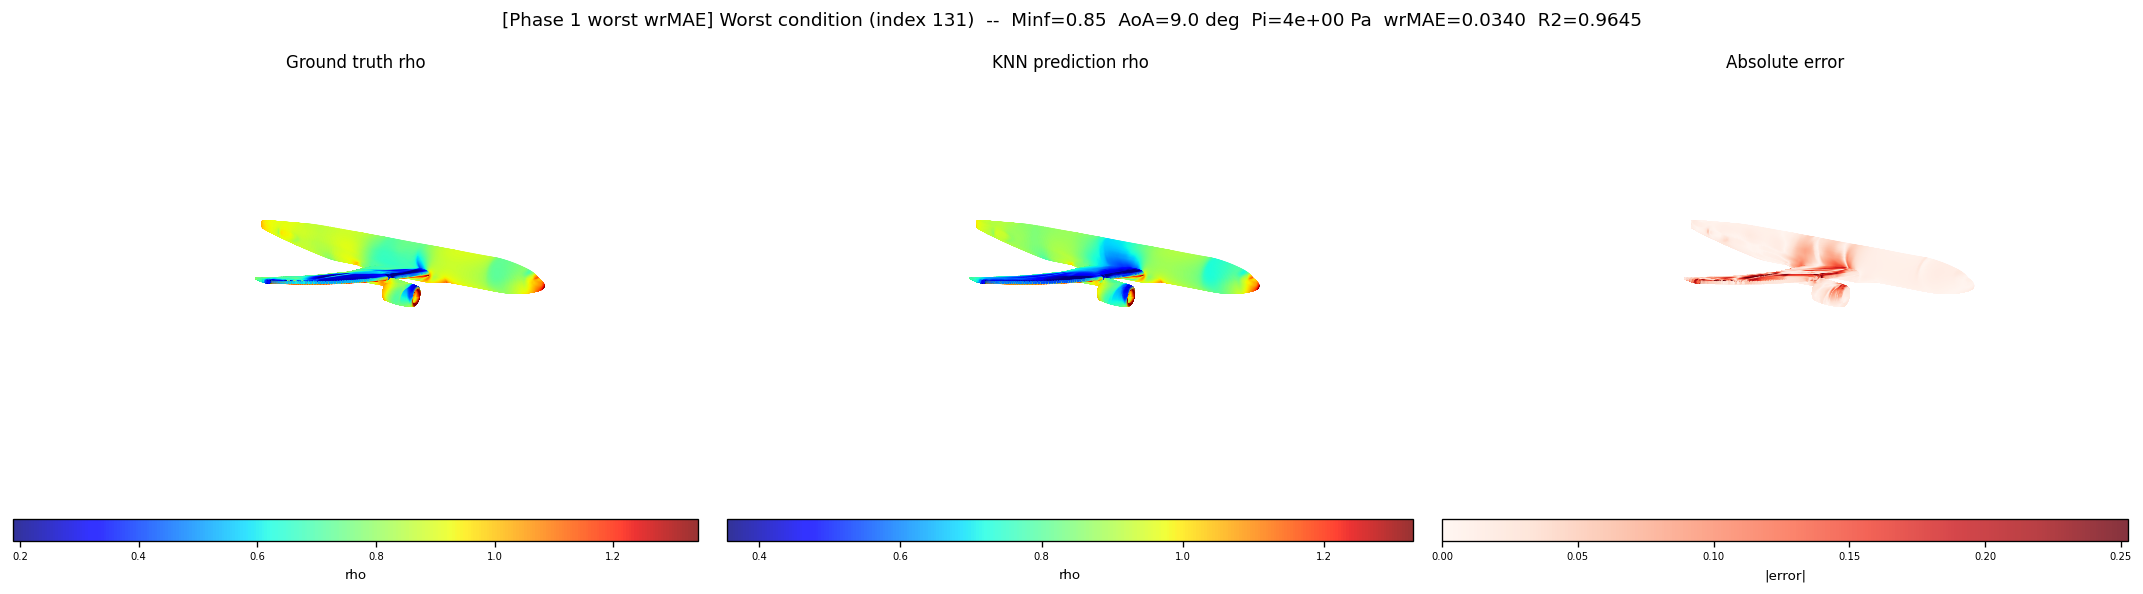

Saved: worst_condition_Phase_1_worst_KL.png


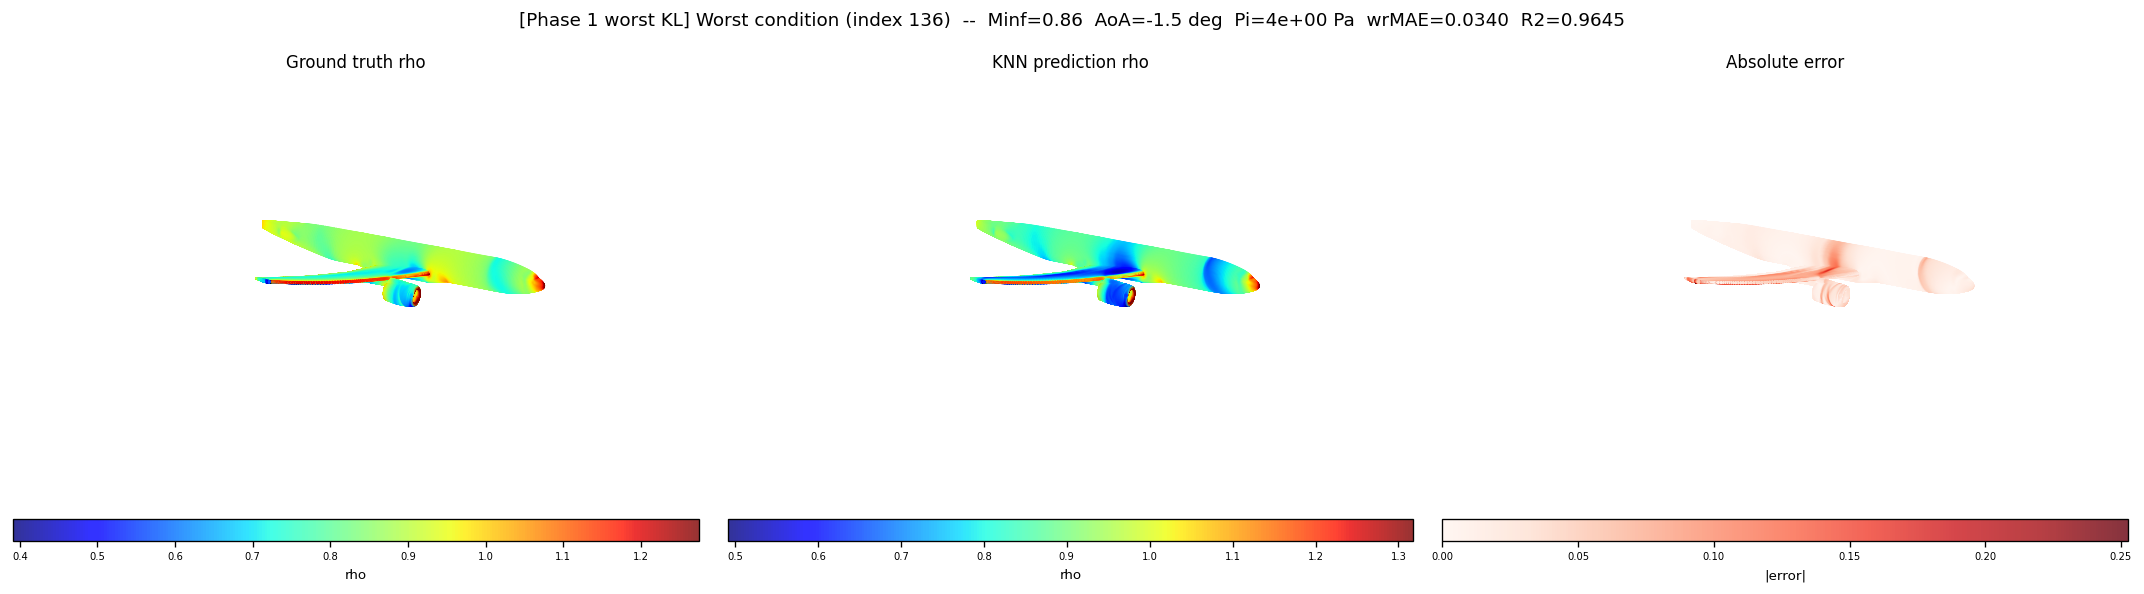

Saved: worst_condition_Phase_2_worst_wrMAE.png


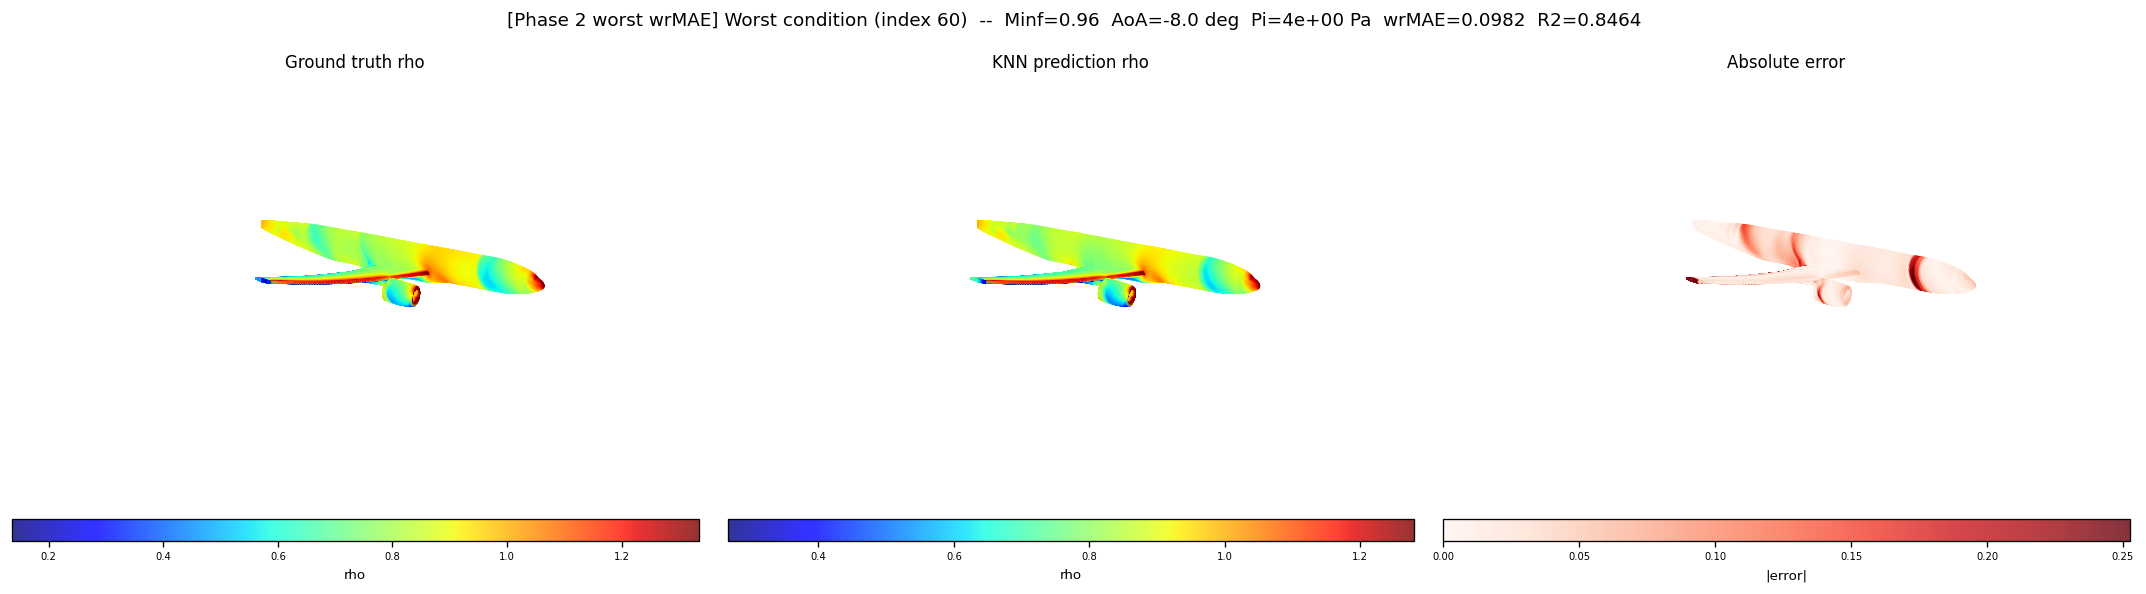

Saved: worst_condition_Phase_2_worst_KL.png


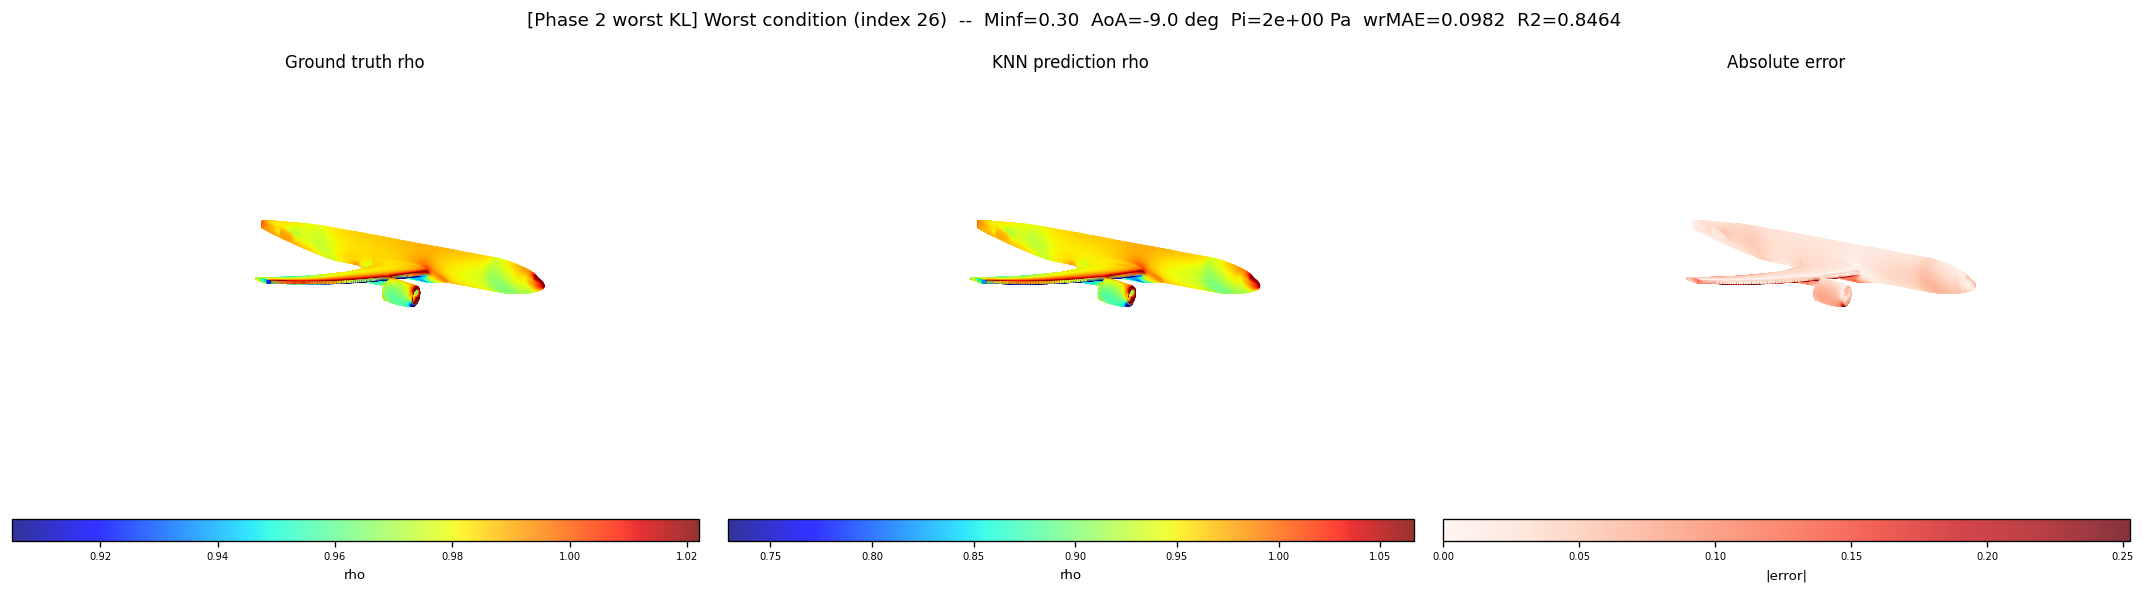

In [16]:
def plot_condition(iworst, X_test, y_test, y_pred, nwallp, wrMAE, phase_label, r2=None, err_vmax=None):
    """3-D scatter of ground truth, prediction and absolute error for one simulation."""
    X_worst    = X_test [iworst * nwallp:(iworst + 1) * nwallp]
    y_worst    = y_test [iworst * nwallp:(iworst + 1) * nwallp]
    yhat_worst = y_pred [iworst * nwallp:(iworst + 1) * nwallp]

    Minf = X_worst[0, COL_MINF]
    AoA  = X_worst[0, COL_AOA]
    Pi   = X_worst[0, COL_PI]

    X_coord = X_worst[:, 0]
    Y_coord = X_worst[:, 1]
    Z_coord = X_worst[:, 2]
    error   = np.abs(y_worst - yhat_worst)

    def _scale(field):
        f03, f50, f97 = np.percentile(field, [3., 50., 97.])
        slopem = (f50 - f03) / 0.47
        slopep = (f97 - f50) / 0.47
        return max(0., f50 - 0.6 * slopem), f50 + 0.6 * slopep

    fields = [y_worst, yhat_worst, error]
    titles = ['Ground truth rho', 'KNN prediction rho', 'Absolute error']
    cmaps  = ['jet', 'jet', 'Reds']

    r2_str = f'  R2={r2:.4f}' if r2 is not None else ''
    fig = plt.figure(figsize=(18, 5), dpi=120)
    fig.suptitle(
        f'[{phase_label}] Worst condition (index {iworst})  --  '
        f'Minf={Minf:.2f}  AoA={AoA:.1f} deg  Pi={Pi:.0e} Pa  wrMAE={wrMAE:.4f}{r2_str}',
        fontsize=11
    )
    for col, (field, title, cmap) in enumerate(zip(fields, titles, cmaps)):
        gs  = gridspec.GridSpec(2, 3, figure=fig, height_ratios=[20, 1])
        ax  = fig.add_subplot(gs[0, col], projection='3d')
        fmin, fmax = _scale(field)
        if col == 2 and err_vmax is not None:
            fmin, fmax = 0.0, err_vmax
        sca = ax.scatter3D(X_coord, Y_coord, Z_coord,
                           c=field, vmin=fmin, vmax=fmax,
                           cmap=cmap, s=0.3, alpha=0.8)
        ax.view_init(elev=20, azim=120)
        ax.set_xlim(X_coord.min() - 5.0, X_coord.max() + 5.0)
        ax.set_ylim(Y_coord.min() - 5.0, Y_coord.max() + 5.0)
        ax.set_zlim(Z_coord.min(), Z_coord.max())
        lims = np.array([getattr(ax, f'get_{a}lim')() for a in 'xyz'])
        ax.set_box_aspect(np.ptp(lims, axis=1), zoom=1.)
        ax.set_axis_off()
        ax.set_title(title, fontsize=10)
        cax  = fig.add_subplot(gs[1, col])
        cbar = fig.colorbar(sca, cax=cax, orientation='horizontal')
        cbar.set_label('rho' if col < 2 else '|error|', size=8)
        cbar.ax.tick_params(labelsize=6)
    plt.tight_layout()
    out = f'worst_condition_{phase_label.replace(" ", "_")}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    print(f'Saved: {out}')
    plt.show()

err_vmax = max(
    np.percentile(np.abs(res1['Y'][res1['iworst']] - res1['Yh'][res1['iworst']]), 97),
    np.percentile(np.abs(res2['Y'][res2['iworst']] - res2['Yh'][res2['iworst']]), 97),
)

for label, X_test, res in [('Phase 1', X_test1, res1), ('Phase 2', X_test2, res2)]:
    iw_mae = res['iworst']
    iw_kl  = int(np.nanargmax(res['kl']))

    plot_condition(iw_mae, X_test, res['Y'].reshape(-1), res['Yh'].reshape(-1), nwallp,
                   res['wrMAE'], f'{label} worst wrMAE', r2=res['r2'], err_vmax=err_vmax)
    plot_condition(iw_kl, X_test, res['Y'].reshape(-1), res['Yh'].reshape(-1), nwallp,
                   res['wrMAE'], f'{label} worst KL', r2=res['r2'], err_vmax=err_vmax)

Saved: worst_condition_Phase_1_worst_wrMAE.png


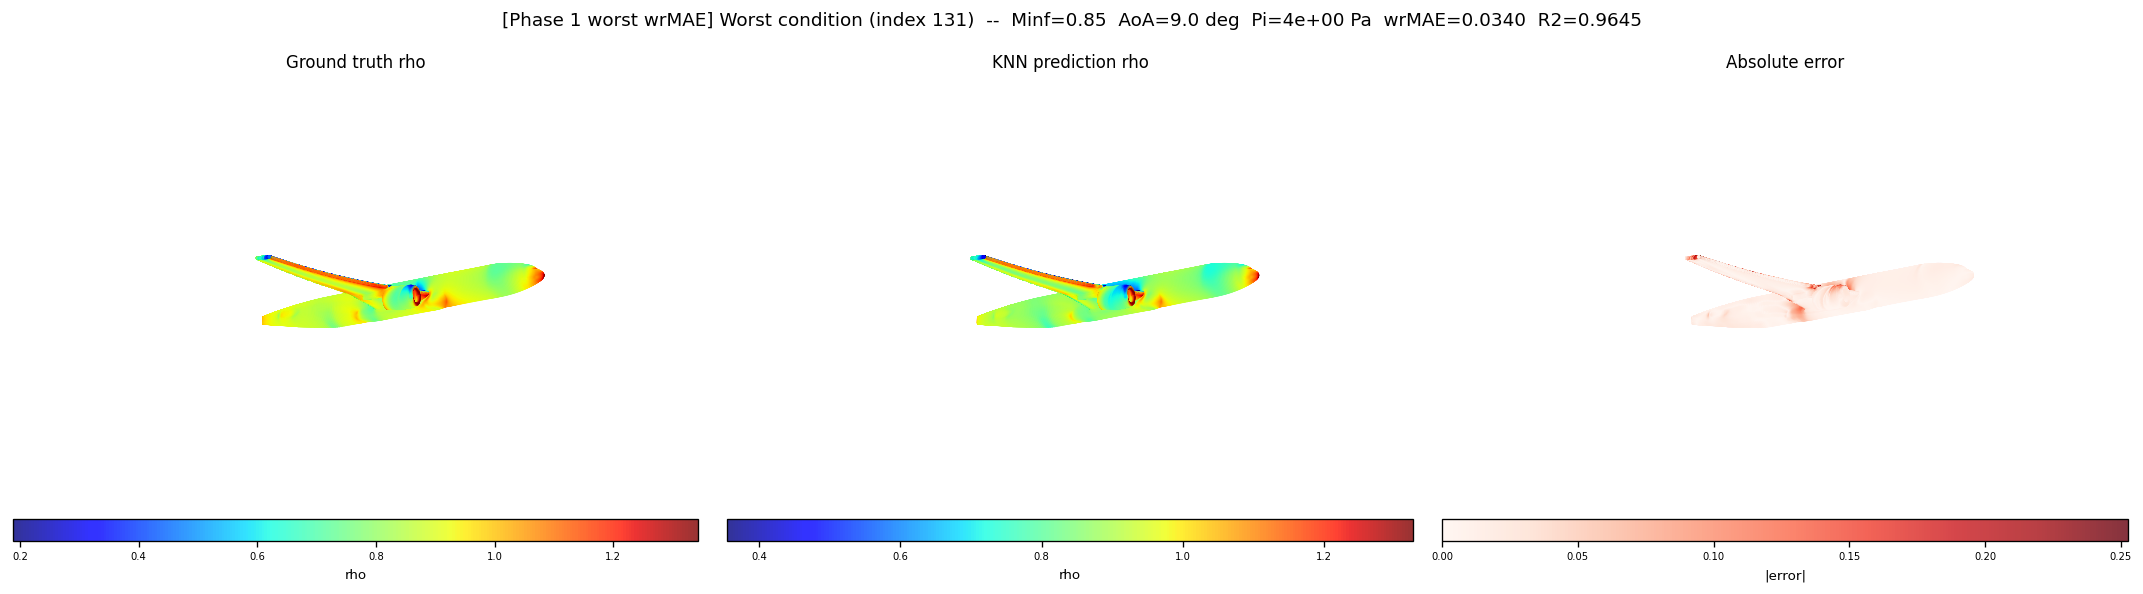

Saved: worst_condition_Phase_1_worst_KL.png


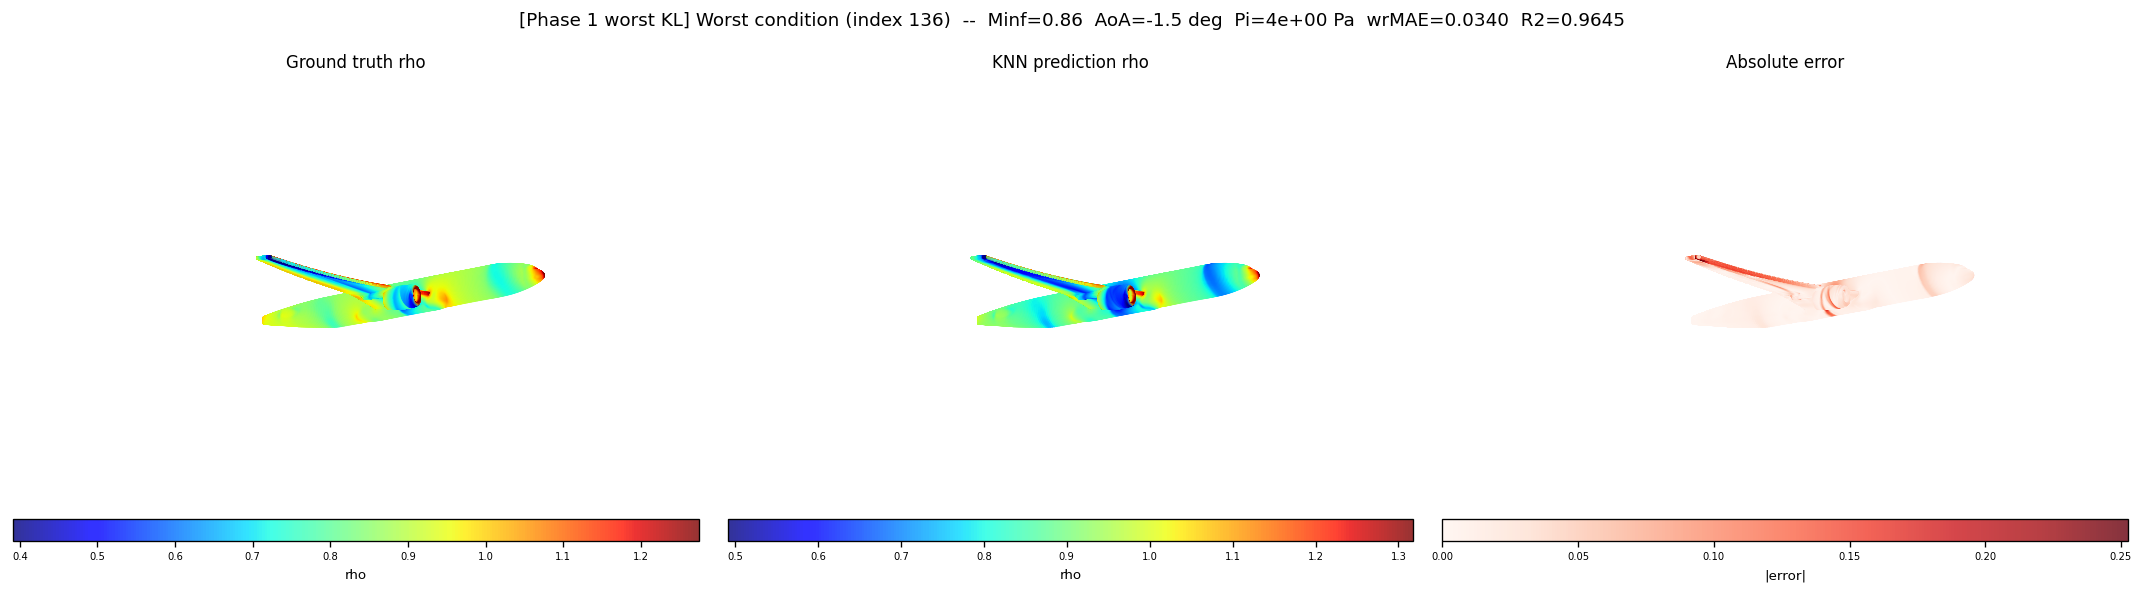

Saved: worst_condition_Phase_2_worst_wrMAE.png


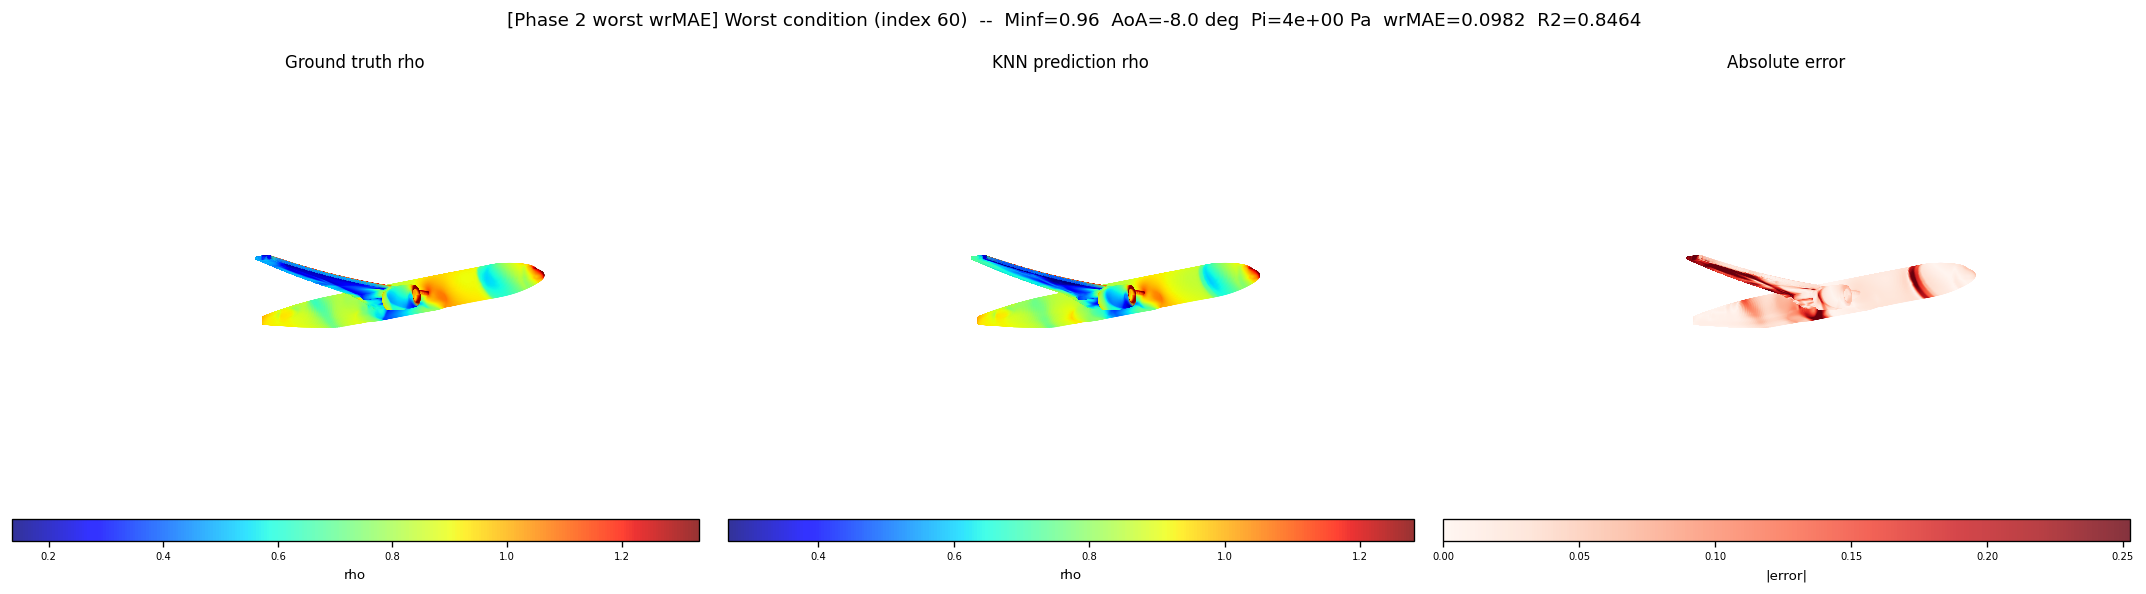

Saved: worst_condition_Phase_2_worst_KL.png


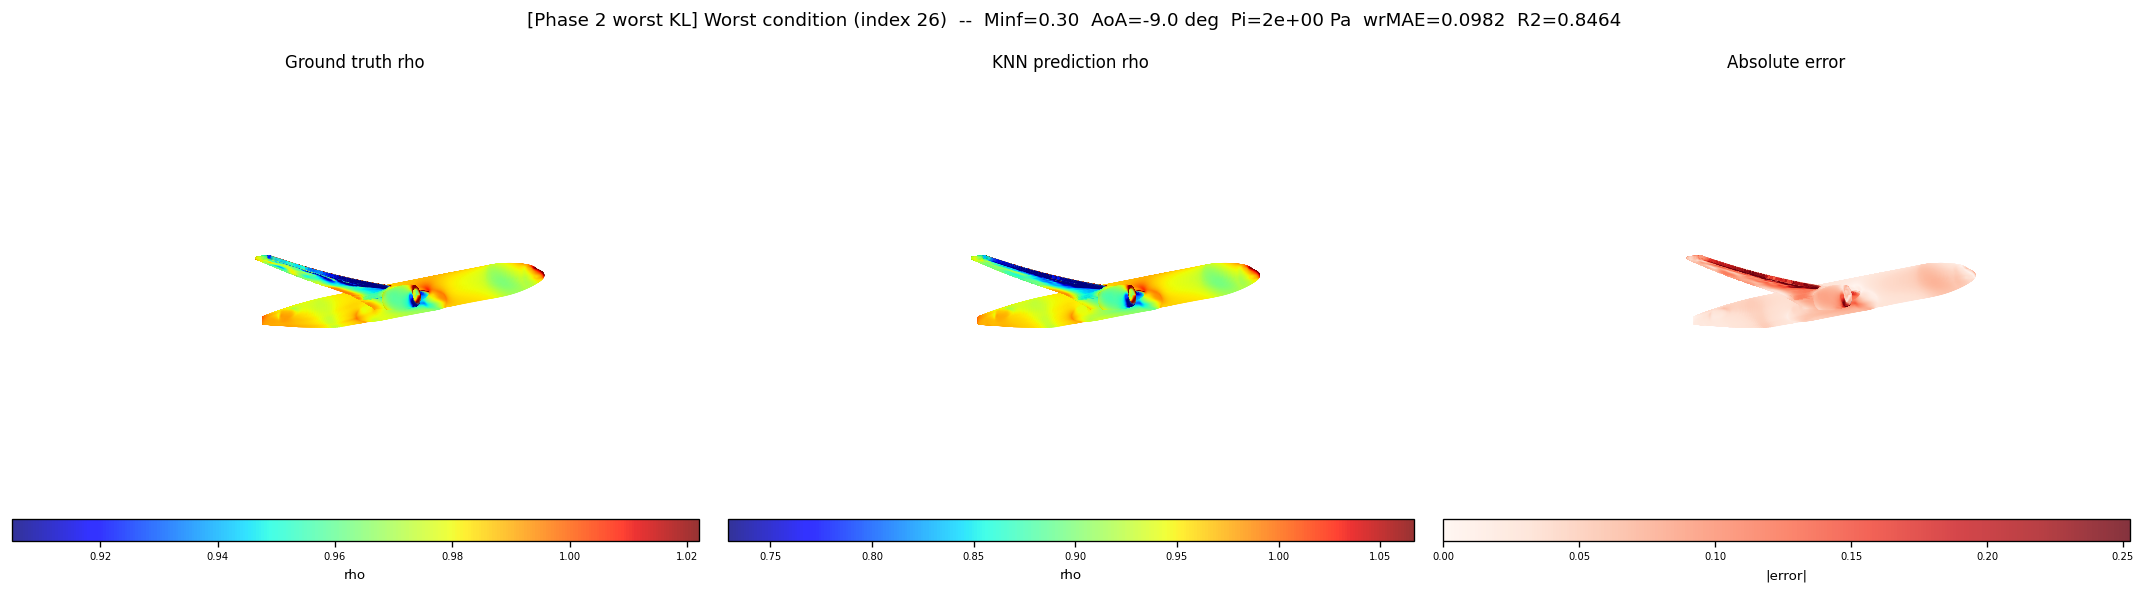

In [17]:
def plot_condition(iworst, X_test, y_test, y_pred, nwallp, wrMAE, phase_label, r2=None, err_vmax=None):
    """3-D scatter of ground truth, prediction and absolute error for one simulation."""
    X_worst    = X_test [iworst * nwallp:(iworst + 1) * nwallp]
    y_worst    = y_test [iworst * nwallp:(iworst + 1) * nwallp]
    yhat_worst = y_pred [iworst * nwallp:(iworst + 1) * nwallp]

    Minf = X_worst[0, COL_MINF]
    AoA  = X_worst[0, COL_AOA]
    Pi   = X_worst[0, COL_PI]

    X_coord = X_worst[:, 0]
    Y_coord = X_worst[:, 1]
    Z_coord = X_worst[:, 2]
    error   = np.abs(y_worst - yhat_worst)

    def _scale(field):
        f03, f50, f97 = np.percentile(field, [3., 50., 97.])
        slopem = (f50 - f03) / 0.47
        slopep = (f97 - f50) / 0.47
        return max(0., f50 - 0.6 * slopem), f50 + 0.6 * slopep

    fields = [y_worst, yhat_worst, error]
    titles = ['Ground truth rho', 'KNN prediction rho', 'Absolute error']
    cmaps  = ['jet', 'jet', 'Reds']

    r2_str = f'  R2={r2:.4f}' if r2 is not None else ''
    fig = plt.figure(figsize=(18, 5), dpi=120)
    fig.suptitle(
        f'[{phase_label}] Worst condition (index {iworst})  --  '
        f'Minf={Minf:.2f}  AoA={AoA:.1f} deg  Pi={Pi:.0e} Pa  wrMAE={wrMAE:.4f}{r2_str}',
        fontsize=11
    )
    for col, (field, title, cmap) in enumerate(zip(fields, titles, cmaps)):
        gs  = gridspec.GridSpec(2, 3, figure=fig, height_ratios=[20, 1])
        ax  = fig.add_subplot(gs[0, col], projection='3d')
        fmin, fmax = _scale(field)
        if col == 2 and err_vmax is not None:
            fmin, fmax = 0.0, err_vmax
        sca = ax.scatter3D(X_coord, Y_coord, Z_coord,
                           c=field, vmin=fmin, vmax=fmax,
                           cmap=cmap, s=0.3, alpha=0.8)
        ax.view_init(elev=-20, azim=120)
        ax.set_xlim(X_coord.min() - 5.0, X_coord.max() + 5.0)
        ax.set_ylim(Y_coord.min() - 5.0, Y_coord.max() + 5.0)
        ax.set_zlim(Z_coord.min(), Z_coord.max())
        lims = np.array([getattr(ax, f'get_{a}lim')() for a in 'xyz'])
        ax.set_box_aspect(np.ptp(lims, axis=1), zoom=1.)
        ax.set_axis_off()
        ax.set_title(title, fontsize=10)
        cax  = fig.add_subplot(gs[1, col])
        cbar = fig.colorbar(sca, cax=cax, orientation='horizontal')
        cbar.set_label('rho' if col < 2 else '|error|', size=8)
        cbar.ax.tick_params(labelsize=6)
    plt.tight_layout()
    out = f'worst_condition_{phase_label.replace(" ", "_")}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    print(f'Saved: {out}')
    plt.show()


err_vmax = max(
    np.percentile(np.abs(res1['Y'][res1['iworst']] - res1['Yh'][res1['iworst']]), 97),
    np.percentile(np.abs(res2['Y'][res2['iworst']] - res2['Yh'][res2['iworst']]), 97),
)

for label, X_test, res in [('Phase 1', X_test1, res1), ('Phase 2', X_test2, res2)]:
    iw_mae = res['iworst']
    iw_kl  = int(np.nanargmax(res['kl']))

    plot_condition(iw_mae, X_test, res['Y'].reshape(-1), res['Yh'].reshape(-1), nwallp,
                   res['wrMAE'], f'{label} worst wrMAE', r2=res['r2'], err_vmax=err_vmax)
    plot_condition(iw_kl, X_test, res['Y'].reshape(-1), res['Yh'].reshape(-1), nwallp,
                   res['wrMAE'], f'{label} worst KL', r2=res['r2'], err_vmax=err_vmax)

Saved: residual_hist_Phase_1_worst_wrMAE.png


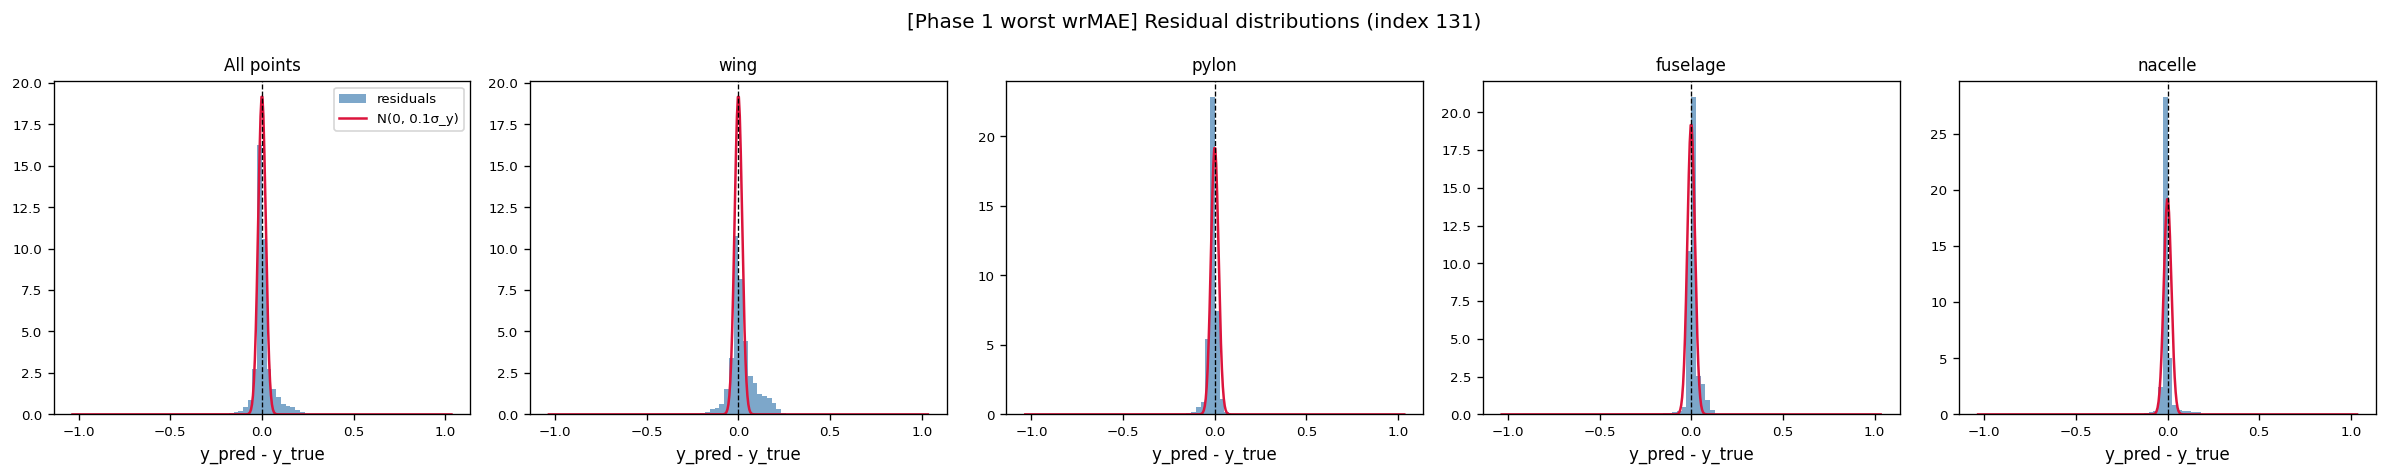

Saved: residual_hist_Phase_1_worst_KL.png


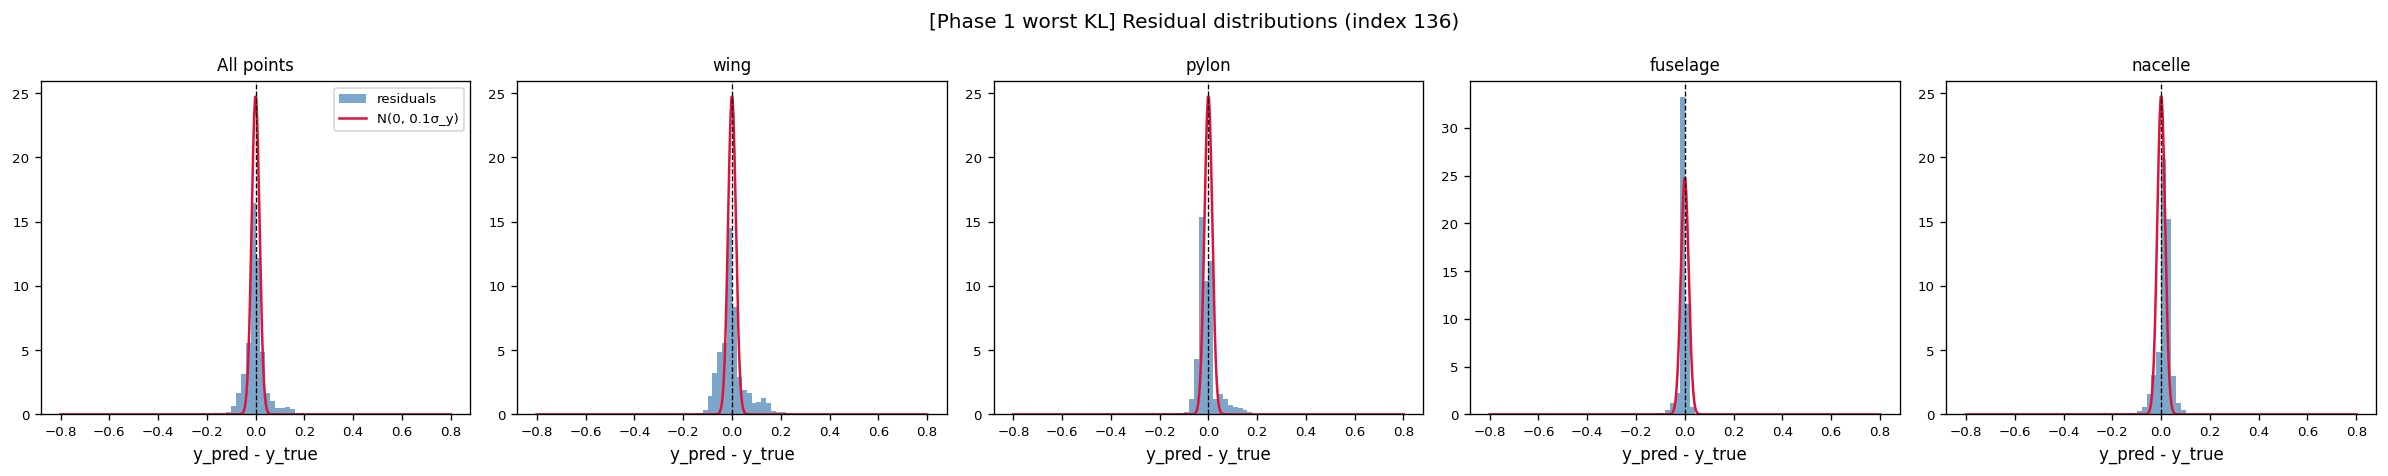

Saved: residual_hist_Phase_2_worst_wrMAE.png


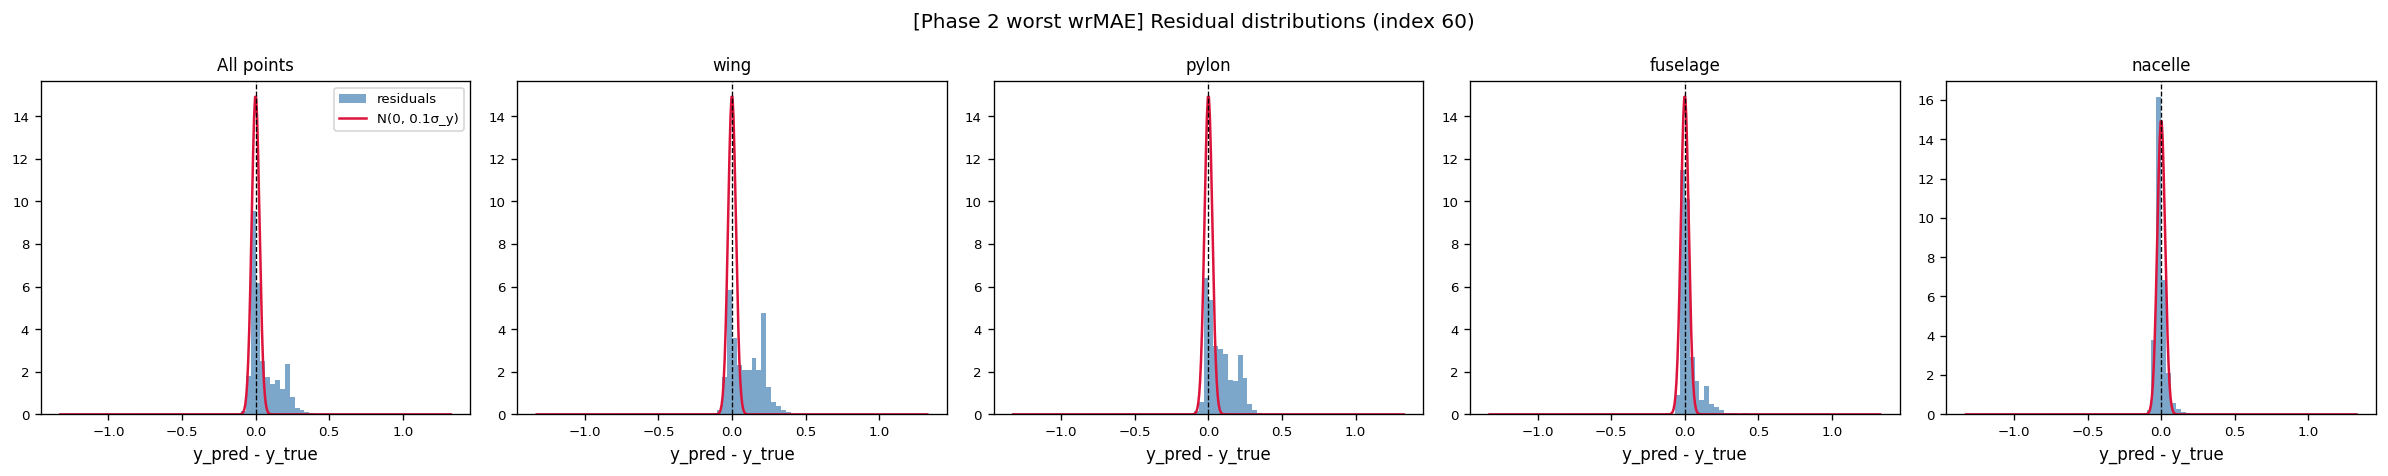

Saved: residual_hist_Phase_2_worst_KL.png


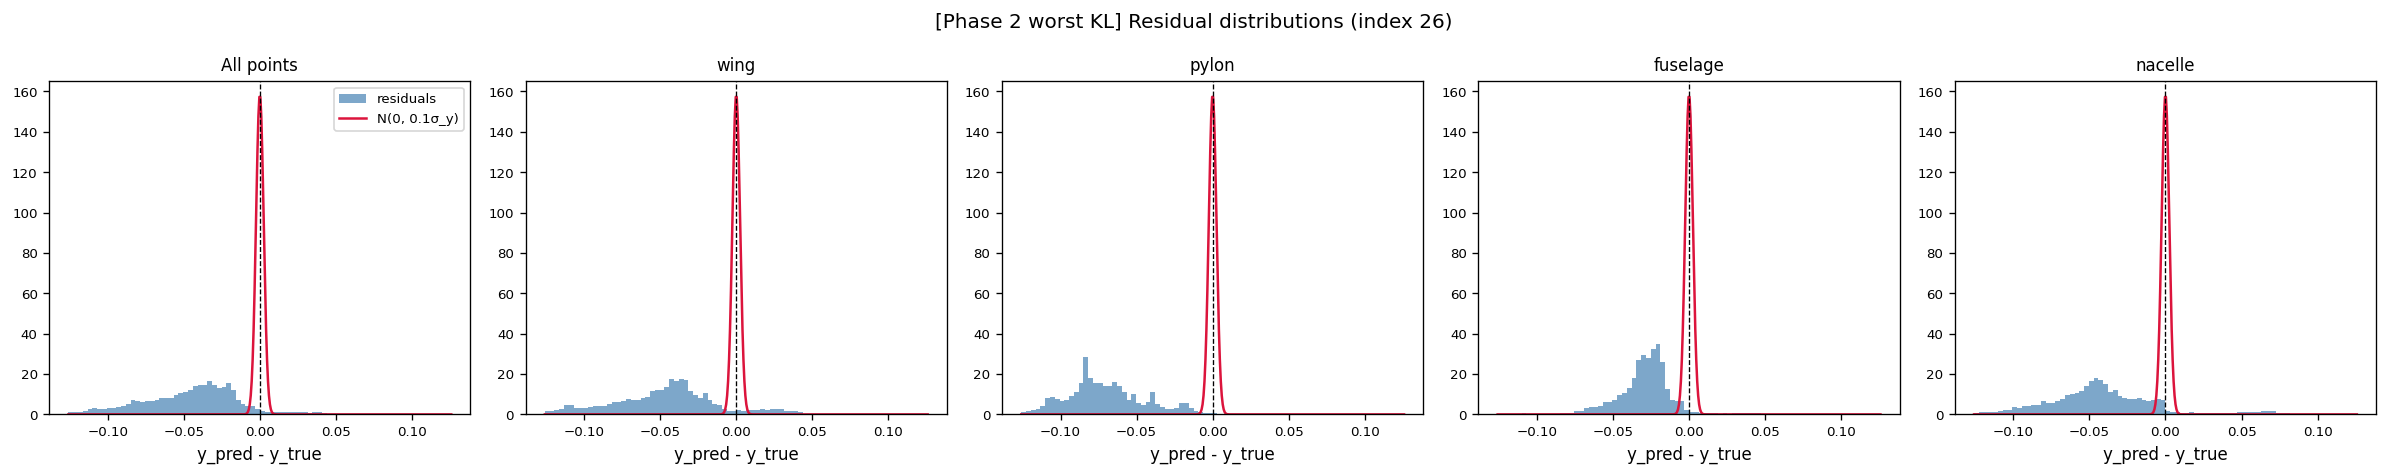

In [18]:
def plot_residual_histograms(iworst, X_test, y_test, y_pred, nwallp, phase_label, n_bins=80):
    """Histograms of signed residuals (y_pred - y_true): global and per component."""
    y_worst    = y_test [iworst * nwallp:(iworst + 1) * nwallp]
    yhat_worst = y_pred [iworst * nwallp:(iworst + 1) * nwallp]
    eps_global = yhat_worst - y_worst
    sigma_y    = y_worst.std() + 1e-12

    comp_names = list(KL_WEIGHTS.keys())
    fig, axes  = plt.subplots(1, len(comp_names) + 1, figsize=(4 * (len(comp_names) + 1), 4), dpi=120)
    fig.suptitle(f'[{phase_label}] Residual distributions (index {iworst})', fontsize=12)

    def _draw(ax, eps, title):
        lim = 5.0 * sigma_y
        bins = np.linspace(-lim, lim, n_bins + 1)
        ax.hist(eps, bins=bins, density=True, color='steelblue', alpha=0.7, label='residuals')
        xx = np.linspace(-lim, lim, 400)
        ax.plot(xx, norm.pdf(xx, loc=0.0, scale=0.1 * sigma_y), color='crimson', lw=1.5, label='N(0, 0.1σ_y)')
        ax.axvline(0.0, color='black', lw=0.8, ls='--')
        ax.set_title(title, fontsize=10)
        ax.set_xlabel('y_pred - y_true')
        ax.tick_params(labelsize=8)

    _draw(axes[0], eps_global, 'All points')
    for ax, cname in zip(axes[1:], comp_names):
        mask = comp_masks[cname]
        _draw(ax, eps_global[mask], cname)

    axes[0].legend(fontsize=8)
    plt.tight_layout()
    out = f'residual_hist_{phase_label.replace(" ", "_")}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    print(f'Saved: {out}')
    plt.show()


for label, X_test, res in [('Phase 1', X_test1, res1), ('Phase 2', X_test2, res2)]:
    iw_mae = res['iworst']
    iw_kl  = int(np.nanargmax(res['kl']))

    plot_residual_histograms(iw_mae, X_test, res['Y'].reshape(-1), res['Yh'].reshape(-1), nwallp, f'{label} worst wrMAE')
    plot_residual_histograms(iw_kl,  X_test, res['Y'].reshape(-1), res['Yh'].reshape(-1), nwallp, f'{label} worst KL')